In [20]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utils.integral import grid
from Models.clustering import EMIFCF, IFCF


In [22]:
# Load th .npz file
IR = 20
noise = 1.00
data = np.load(f"../dataset/G_{noise:.2f}_data_{IR}.npz")
F_data = data['G_data']
grid_x = data['grid_x']
labels = data['labels']
bandwidth = data['bandwidth']

In [23]:
# ==== Các biến khởi tạo cho EM-IFCM ====
grid_x         = grid_x          # (np.ndarray) lưới rời rạc cho PDF
num_clusters   = 2               # (int) số cụm K
fuzziness      = 2               # (float) m > 1
max_iterations = 200             # (int) số vòng lặp tối đa
tolerance      = 1e-6            # (float) ngưỡng hội tụ
init           = 'k'        # (str) khởi tạo tâm: 'random' | 'kmeans++'
bandwidth      = bandwidth       # (float) h cho khoảng cách kernel
distance_metric= 'W2'            # (str) tên metric trong Dist: 'L1','L2','H','BC','KL',...
verbose        = True            # (bool) in log hay không
Dim            = None            # (int | None) 1D hoặc 2D PDF
seed           = None            # (int | None) random seed
eps            = 1e-12           # (float) epsilon chống chia 0

In [24]:
cluster_IFCF = IFCF.Model(
    grid_x=grid_x,
    num_clusters=num_clusters,
    fuzziness=fuzziness,
    max_iterations=max_iterations,
    tolerance=tolerance,
    init=init,
    bandwidth=bandwidth,
    distance_metric=distance_metric,
    verbose=verbose,
    Dim=Dim,
    seed=seed,
    eps=eps,
)

cluster_IFCF.fit(F_data)
U_IFCF, Theta_IFCF, J_IFCM = cluster_IFCF.get_results()
labels_IFCF = cluster_IFCF.get_hard_assignments()

[IFCM] it=001 | dU=2.402e+01 | dTheta=1.154e+00 | ΔJ=inf | J=2.363576e+05 | f=[0.5074127 0.4925873]
[IFCM] it=002 | dU=1.317e+00 | dTheta=9.138e-02 | ΔJ=1.931e+05 | J=4.329929e+04 | f=[0.93252003 0.06747997]
[IFCM] it=003 | dU=2.221e-01 | dTheta=7.389e-03 | ΔJ=6.961e+02 | J=4.399540e+04 | f=[0.95291194 0.04708806]
[IFCM] it=004 | dU=2.107e-02 | dTheta=9.370e-04 | ΔJ=9.161e+01 | J=4.408701e+04 | f=[0.95363793 0.04636207]
[IFCM] it=005 | dU=2.523e-03 | dTheta=1.232e-04 | ΔJ=7.864e+00 | J=4.409488e+04 | f=[0.95368618 0.04631382]
[IFCM] it=006 | dU=3.253e-04 | dTheta=1.633e-05 | ΔJ=8.181e-01 | J=4.409569e+04 | f=[0.95369041 0.04630959]
[IFCM] it=007 | dU=4.287e-05 | dTheta=2.173e-06 | ΔJ=9.732e-02 | J=4.409579e+04 | f=[0.95369087 0.04630913]
[IFCM] it=008 | dU=5.691e-06 | dTheta=2.894e-07 | ΔJ=1.238e-02 | J=4.409580e+04 | f=[0.95369092 0.04630908]
[IFCM] it=009 | dU=7.572e-07 | dTheta=3.856e-08 | ΔJ=1.620e-03 | J=4.409580e+04 | f=[0.95369093 0.04630907]
[IFCM] it=010 | dU=1.009e-07 | dThet

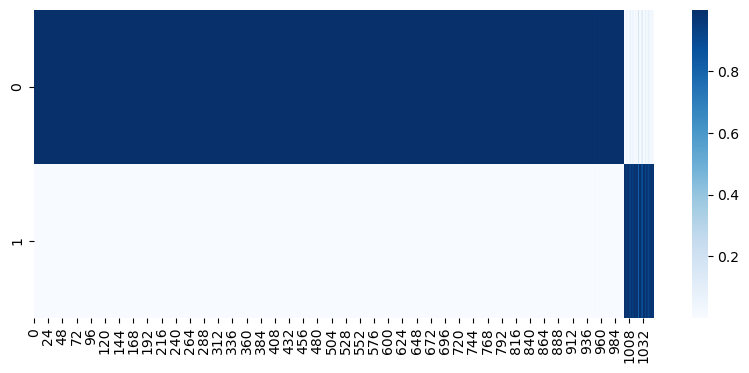

In [25]:
# Vẽ đồ thị
plt.figure(figsize=(10, 4))
plt.heatmap = sns.heatmap
plt.heatmap(U_IFCF, cmap='Blues', cbar=True)
plt.show()
